# Python-Spickzettel für Übung 2

Dieser Spickzettel dient nur als kurze Einführung vor der Übung.  
Er verwendet keine Daten und keine Aufgaben aus der eigentlichen Übung.

Die Erklärungen stehen in Markdown-Zellen. Die Code-Zellen darunter können einzeln ausgeführt werden.

## 1. Neue Bibliotheken

`scipy.stats` enthält statistische Funktionen. Hier wird daraus eine einfache lineare Regression verwendet.

`folium` erstellt interaktive Karten, auf denen Punkte oder Marker dargestellt werden können.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import folium


## 2. Kleine Beispieldaten

Diese Tabelle ist nur ein neutrales Beispiel. Sie dient dazu, die neuen Befehle ausprobieren zu können.

In [2]:
df = pd.DataFrame(  # erstellt eine Tabelle, also einen pandas-DataFrame
    {
        "Standort": ["A", "B", "C", "D", "E", "F", "G", "H"],  # Textspalte mit Standortnamen
        "Region": ["Nord", "Nord", "Sued", "Sued", "West", "West", "Ost", "Ost"],  # Gruppierungsmerkmal
        "Typ": ["Typ A", "Typ B", "Typ A", "Typ C", "Typ B", "Typ C", "Typ A", "Typ B"],  # Kategorie pro Standort
        "Jahr": [2018, 2019, 2020, 2020, 2021, 2022, 2022, 2023],  # Zahlenwerte für das Jahr
        "Leistung_MW": [12.5, 30.0, 22.0, 44.0, 18.0, 50.0, 27.0, 33.0],  # numerische Beispielwerte
        "Kosten": [2100, 1850, 2300, np.nan, 1950, 2700, 2200, 2000],  # np.nan steht für einen fehlenden Wert
        "Speicher_h": [2, 4, 3, 8, 5, np.nan, 6, 7],  # weitere numerische Beispielwerte mit einem fehlenden Wert
        "Koordinaten": [
            "48.1,11.6", "52.5,13.4", "50.1,8.7", "53.6,10.0",
            "51.2,6.8", "49.5,11.1", "51.0,13.7", "48.8,9.2"], # Textspalte, in der zwei Informationen in einem String stehen
    }
)

df  # zeigt die Tabelle im Notebook an


,Standort,Region,Typ,Jahr,Leistung_MW,Kosten,Speicher_h,Koordinaten
0,A,Nord,Typ A,2018,12.5,2100.0,2.0,"48.1,11.6"
1,B,Nord,Typ B,2019,30.0,1850.0,4.0,"52.5,13.4"
2,C,Sued,Typ A,2020,22.0,2300.0,3.0,"50.1,8.7"
3,D,Sued,Typ C,2020,44.0,NaN,8.0,"53.6,10.0"
4,E,West,Typ B,2021,18.0,1950.0,5.0,"51.2,6.8"
5,F,West,Typ C,2022,50.0,2700.0,NaN,"49.5,11.1"
6,G,Ost,Typ A,2022,27.0,2200.0,6.0,"51.0,13.7"
7,H,Ost,Typ B,2023,33.0,2000.0,7.0,"48.8,9.2"


## 3. Einzelne Werte mit `loc` ändern

Mit `loc` kann gezielt eine bestimmte Zeile und eine bestimmte Spalte angesprochen werden.

Allgemeine Form:

```python
df.loc[zeile, "spalte"]
```

In [3]:
df.loc[2, "Jahr"] = 2024  # ändert den Wert in Zeile mit Index 2 und Spalte "Jahr" auf 2024

df.loc[[2], ["Standort", "Jahr"]]  # zeigt nur die Zeile mit Index 2 und die Spalten "Standort" und "Jahr"


,Standort,Jahr
2,C,2024


## 4. Zeilen mit einer Bedingung filtern

Mit einer Bedingung in eckigen Klammern werden nur die Zeilen angezeigt, für die die Bedingung wahr ist.

In [4]:
df[df["Region"] == "Nord"] # df["Region"] == "Nord" erzeugt eine True/False-Bedingung für jede Zeile; df[...] zeigt anschließend nur die Zeilen an, für die die Bedingung True ist


,Standort,Region,Typ,Jahr,Leistung_MW,Kosten,Speicher_h,Koordinaten
0,A,Nord,Typ A,2018,12.5,2100.0,2.0,"48.1,11.6"
1,B,Nord,Typ B,2019,30.0,1850.0,4.0,"52.5,13.4"


## 5. Mehrere erlaubte Werte mit `isin` filtern

`isin(...)` prüft, ob ein Eintrag in einer Liste vorkommt.

In [5]:
df[df["Typ"].isin(["Typ A", "Typ B"])]  # wählt nur Zeilen aus, deren "Typ" in der angegebenen Liste vorkommt


,Standort,Region,Typ,Jahr,Leistung_MW,Kosten,Speicher_h,Koordinaten
0,A,Nord,Typ A,2018,12.5,2100.0,2.0,"48.1,11.6"
1,B,Nord,Typ B,2019,30.0,1850.0,4.0,"52.5,13.4"
2,C,Sued,Typ A,2024,22.0,2300.0,3.0,"50.1,8.7"
4,E,West,Typ B,2021,18.0,1950.0,5.0,"51.2,6.8"
6,G,Ost,Typ A,2022,27.0,2200.0,6.0,"51.0,13.7"
7,H,Ost,Typ B,2023,33.0,2000.0,7.0,"48.8,9.2"


## 6. Text in einer Spalte aufteilen

`str.split(...)` trennt Textwerte an einem Trennzeichen.

`expand=True` sorgt dafür, dass aus den getrennten Teilen neue Spalten entstehen.

In [6]:
df[["Breitengrad", "Laengengrad"]] = df["Koordinaten"].str.split( #Koordinaten ist die ursprüngliche Spalte, Breitengrad und Laengengrad die Neuen
    ",",  # Trennzeichen: hier wird der Text am Komma getrennt
    expand=True  # gibt die getrennten Teile als eigene Spalten zurück
)

df[["Standort", "Koordinaten", "Breitengrad", "Laengengrad"]]  # zeigt die ursprüngliche und die neuen Spalten an


,Standort,Koordinaten,Breitengrad,Laengengrad
0,A,"48.1,11.6",48.1,11.6
1,B,"52.5,13.4",52.5,13.4
2,C,"50.1,8.7",50.1,8.7
3,D,"53.6,10.0",53.6,10.0
4,E,"51.2,6.8",51.2,6.8
5,F,"49.5,11.1",49.5,11.1
6,G,"51.0,13.7",51.0,13.7
7,H,"48.8,9.2",48.8,9.2


## 7. Datentyp ändern mit `astype`

Nach dem Aufteilen sind die Koordinaten noch als Text formatiert.

Mit `astype(float)` werden daraus Dezimalzahlen.

In [7]:
df[["Breitengrad", "Laengengrad"]] = df[["Breitengrad", "Laengengrad"]].astype(float)  # wandelt Textwerte in Dezimalzahlen um

df[["Standort", "Breitengrad", "Laengengrad"]]  # zeigt die umgewandelten Koordinatenwerte an


,Standort,Breitengrad,Laengengrad
0,A,48.1,11.6
1,B,52.5,13.4
2,C,50.1,8.7
3,D,53.6,10.0
4,E,51.2,6.8
5,F,49.5,11.1
6,G,51.0,13.7
7,H,48.8,9.2


## 8. Fehlende Werte entfernen

`NaN` bedeutet, dass ein Wert fehlt.

`dropna(subset=[...])` entfernt nur Zeilen, in denen in den angegebenen Spalten Werte fehlen.

In [8]:
df.dropna(subset=["Kosten", "Speicher_h"])  # entfernt Zeilen, falls in "Kosten" oder "Speicher_h" ein Wert fehlt


,Standort,Region,Typ,Jahr,Leistung_MW,Kosten,Speicher_h,Koordinaten,Breitengrad,Laengengrad
0,A,Nord,Typ A,2018,12.5,2100.0,2.0,"48.1,11.6",48.1,11.6
1,B,Nord,Typ B,2019,30.0,1850.0,4.0,"52.5,13.4",52.5,13.4
2,C,Sued,Typ A,2024,22.0,2300.0,3.0,"50.1,8.7",50.1,8.7
4,E,West,Typ B,2021,18.0,1950.0,5.0,"51.2,6.8",51.2,6.8
6,G,Ost,Typ A,2022,27.0,2200.0,6.0,"51.0,13.7",51.0,13.7
7,H,Ost,Typ B,2023,33.0,2000.0,7.0,"48.8,9.2",48.8,9.2


## 9. Vorhandene Werte mit `pd.notna` auswählen

`pd.notna(...)` prüft, ob ein Wert vorhanden ist.
In Kombination mit `loc` werden nur diese Zeilen ausgewählt.

In [9]:
df.loc[pd.notna(df["Speicher_h"])]  # wählt nur Zeilen aus, in denen "Speicher_h" nicht leer/NaN ist


,Standort,Region,Typ,Jahr,Leistung_MW,Kosten,Speicher_h,Koordinaten,Breitengrad,Laengengrad
0,A,Nord,Typ A,2018,12.5,2100.0,2.0,"48.1,11.6",48.1,11.6
1,B,Nord,Typ B,2019,30.0,1850.0,4.0,"52.5,13.4",52.5,13.4
2,C,Sued,Typ A,2024,22.0,2300.0,3.0,"50.1,8.7",50.1,8.7
3,D,Sued,Typ C,2020,44.0,NaN,8.0,"53.6,10.0",53.6,10.0
4,E,West,Typ B,2021,18.0,1950.0,5.0,"51.2,6.8",51.2,6.8
6,G,Ost,Typ A,2022,27.0,2200.0,6.0,"51.0,13.7",51.0,13.7
7,H,Ost,Typ B,2023,33.0,2000.0,7.0,"48.8,9.2",48.8,9.2


## 10. Daten gruppieren mit `groupby`

`groupby(...)` fasst Zeilen nach gleichen Werten in einer Spalte zusammen.
Danach kann pro Gruppe gerechnet werden.

In [10]:
df.groupby("Region").count()  # gruppiert nach "Region" und zählt pro Gruppe die vorhandenen Werte je Spalte, die nicht NaN sind


,Standort,Typ,Jahr,Leistung_MW,Kosten,Speicher_h,Koordinaten,Breitengrad,Laengengrad
Region,,,,,,,,,
Nord,2,2,2,2,2,2,2,2,2
Ost,2,2,2,2,2,2,2,2,2
Sued,2,2,2,2,1,2,2,2,2
West,2,2,2,2,2,1,2,2,2


Hier wird pro Region die Gesamtleistung berechnet.

`reset_index()` macht aus dem Gruppenergebnis wieder eine normale Tabelle.

In [11]:
leistung_pro_region = (  # speichert das Ergebnis in einer neuen Variable
    df.groupby("Region")["Leistung_MW"]  # gruppiert nach "Region" und betrachtet nur die Spalte "Leistung_MW"
    .sum()  # summiert die Leistung innerhalb jeder Region
    .reset_index() # verschiebt die Gruppierungsvariable ("Region") vom Index zurück in eine normale Spalte
)

leistung_pro_region  # zeigt die neue Tabelle an


,Region,Leistung_MW
0,Nord,42.5
1,Ost,60.0
2,Sued,66.0
3,West,68.0


## 11. Ergebnisse sortieren

`sort_values(...)` sortiert eine Tabelle nach den Werten einer Spalte.

`ascending=False` bedeutet: größte Werte zuerst.

In [12]:
(
    df.groupby("Region")["Kosten"]  # gruppiert nach "Region" und betrachtet nur die Spalte "Kosten"
    .mean()  # berechnet den Mittelwert der Kosten pro Region
    .sort_values(ascending=False)  # sortiert absteigend, also größte Werte zuerst
    .reset_index()  # macht aus dem Ergebnis wieder eine normale Tabelle
)


,Region,Kosten
0,West,2325.0
1,Sued,2300.0
2,Ost,2100.0
3,Nord,1975.0


## 12. Häufigkeiten zählen mit `value_counts`

`value_counts()` zählt, wie oft jeder Wert in einer Spalte vorkommt.

In [13]:
df["Typ"].value_counts()  # zählt, wie oft jeder Wert in der Spalte "Typ" vorkommt


Typ
Typ A    3
Typ B    3
Typ C    2
Name: count, dtype: int64

## 13. Tabellen verbinden mit `merge`

`pd.merge(...)` verbindet zwei Tabellen über eine gemeinsame Spalte.

`on="Region"` bedeutet hier: Die Spalte `Region` ist der gemeinsame Schlüssel.

In [14]:
koord_pro_region = (  # speichert das Ergebnis in einer neuen Variable
    df.groupby("Region")[["Breitengrad", "Laengengrad"]]  # gruppiert nach "Region" und wählt zwei Spalten aus
    .mean()  # berechnet den Mittelwert der Koordinaten pro Region
    .reset_index()  # macht "Region" wieder zu einer normalen Spalte
)

pd.merge(
    leistung_pro_region,  # erste Tabelle, unter 10. erstellt
    koord_pro_region,  # zweite Tabelle
    on="Region"  # gemeinsame Spalte, über die beide Tabellen verbunden werden
)


,Region,Leistung_MW,Breitengrad,Laengengrad
0,Nord,42.5,50.30,12.50
1,Ost,60.0,49.90,11.45
2,Sued,66.0,51.85,9.35
3,West,68.0,50.35,8.95


## 14. Punktdiagramm mit `scatter`

Ein Punktdiagramm zeigt den Zusammenhang zwischen zwei numerischen Größen.

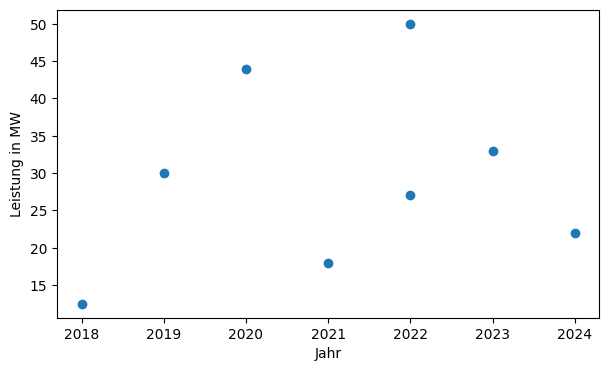

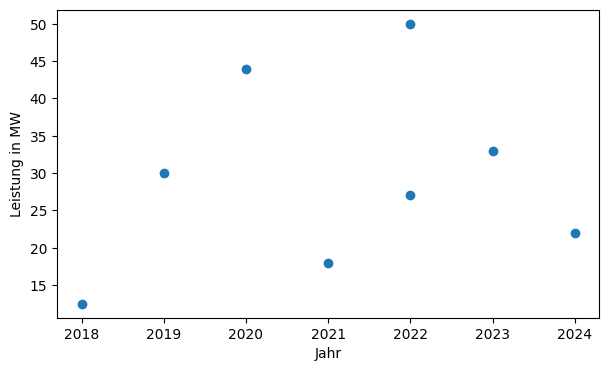

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))  # erstellt eine Zeichenfläche; figsize gibt die Größe (Breite, Höhe) in Zoll an
ax.scatter(df["Jahr"], df["Leistung_MW"])  # Punktdiagramm mit x-Werten "Jahr" und y-Werten "Leistung_MW"
ax.set_xlabel("Jahr")  # Beschriftung der x-Achse
ax.set_ylabel("Leistung in MW")  # Beschriftung der y-Achse
fig  # zeigt die Grafik im Notebook an


## 15. Balken und Fehlerbalken

`ax.bar(...)` zeichnet Balken.

`ax.errorbar(...)` ergänzt Fehlerbalken, zum Beispiel für eine Streuung oder Unsicherheit.

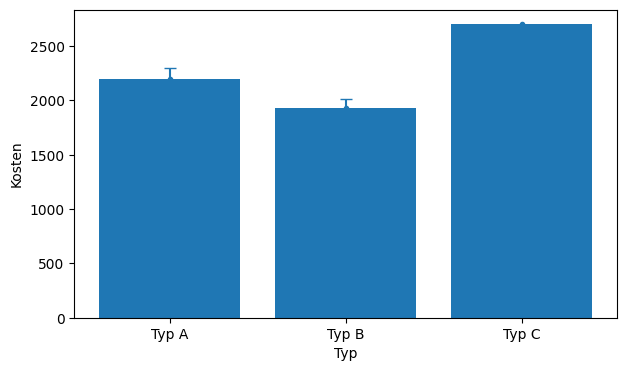

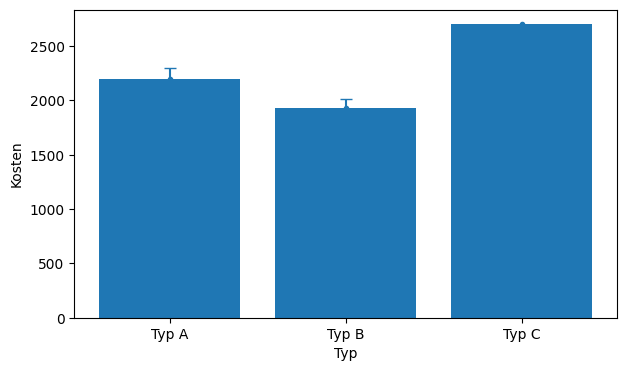

In [16]:
mittelwerte = df.groupby("Typ")["Kosten"].mean()  # berechnet die mittleren Kosten pro Typ
streuung = df.groupby("Typ")["Kosten"].std()  # berechnet die Standardabweichung der Kosten pro Typ

fig, ax = plt.subplots(figsize=(7, 4)) 
ax.bar(mittelwerte.index, mittelwerte)  # zeichnet Balken; x-Positionen sind die Typen, Balkenhöhen die Mittelwerte
ax.errorbar(
    mittelwerte.index,  # x-Positionen der Fehlerbalken
    mittelwerte,  # y-Positionen, also die Höhe der Mittelwerte
    yerr=streuung,  # Länge der Fehlerbalken in y-Richtung
    fmt=".",  # Markerformat: hier ein Punkt
    capsize=4  # Breite der kleinen Querstriche am Ende der Fehlerbalken
)
ax.set_xlabel("Typ")  # Beschriftung der x-Achse
ax.set_ylabel("Kosten")  # Beschriftung der y-Achse
fig  # zeigt die Grafik im Notebook an


## 16. Lineare Regression

`stats.linregress(x, y)` berechnet eine Ausgleichsgerade für zwei Datenreihen.

Wichtige Rückgabewerte sind:

- `slope`: Steigung der Geraden
- `intercept`: Achsenabschnitt der Geraden

`np.linspace(start, stop, anzahl)` erzeugt gleichmäßig verteilte x-Werte für die Trendlinie.

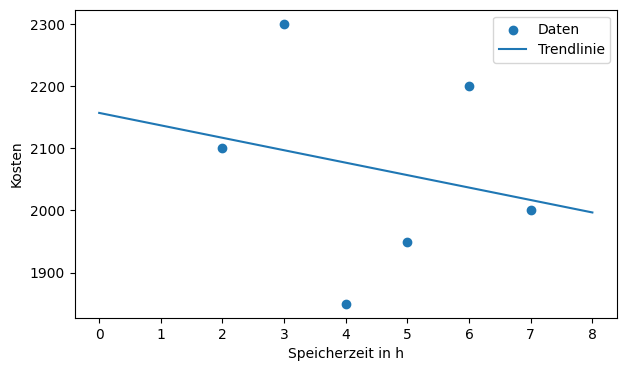

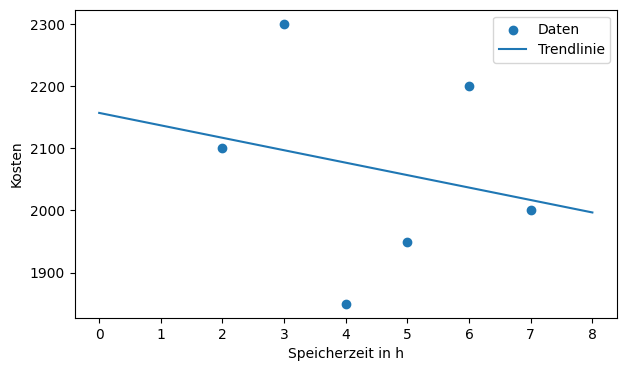

In [17]:
df_reg = df.dropna(subset=["Speicher_h", "Kosten"])  # entfernt Zeilen mit fehlenden x- oder y-Werten für die Regression

slope, intercept, r_value, p_value, std_err = stats.linregress( # verteilt das Ergebnis auf mehrere Eingangsvariablen (slope, intercept, ...)
    df_reg["Speicher_h"],  # x-Werte für die Regression
    df_reg["Kosten"]  # y-Werte für die Regression
)

x = np.linspace(0, 8, 100)  # erzeugt 100 gleichmäßig verteilte x-Werte zwischen 0 und 8
y = slope * x + intercept  # berechnet die y-Werte der Ausgleichsgeraden: y = Steigung * x + Achsenabschnitt

fig, ax = plt.subplots(figsize=(7, 4))  # erstellt eine Zeichenfläche; figsize gibt die Größe in Zoll an
ax.scatter(df_reg["Speicher_h"], df_reg["Kosten"], label="Daten")  # zeichnet die Datenpunkte; label ist der Name in der Legende
ax.plot(x, y, label="Trendlinie")  # zeichnet die berechnete Ausgleichsgerade
ax.set_xlabel("Speicherzeit in h")  # Beschriftung der x-Achse
ax.set_ylabel("Kosten")  # Beschriftung der y-Achse
ax.legend()  # zeigt die Legende mit den labels an
fig  # zeigt die Grafik im Notebook an


## 17. Karte mit `folium`

`folium.Map(...)` erstellt eine interaktive Karte.

`folium.Marker(...)` setzt einen Marker auf die Karte.

`.add_to(karte)` fügt den Marker zur Karte hinzu.

In [22]:
karte = folium.Map(
    location=[51, 10],  # Mittelpunkt der Karte als [Breitengrad, Laengengrad]
    zoom_start=5  # Start-Zoomstufe: größere Werte bedeuten stärker hineingezoomt
)

for index, row in df.iterrows():  # geht Zeile für Zeile durch den DataFrame; row enthält die Werte der aktuellen Zeile
    folium.Marker(
        location=[row["Breitengrad"], row["Laengengrad"]],  # Position des Markers aus den Koordinatenspalten
        popup=folium.Popup(row["Standort"], max_width=100),  # Textfenster beim Anklicken; max_width begrenzt die Breite
    ).add_to(karte)  # fügt den Marker zur Karte hinzu

karte  # zeigt die interaktive Karte im Notebook an


## Ende

Dieser Spickzettel zeigt nur die grundlegende Bedienung der wichtigsten Funktionen.  
Die eigentliche Anwendung auf reale Daten passiert erst in der Übung.